# Analisis Sentimen pada Ulasan Play Store
Notebook ini menunjukkan cara untuk melakukan analisis sentimen pada ulasan aplikasi di Play Store dengan menggunakan **machine learning** dan **deep learning**. Tiga percobaan pelatihan dilakukan dengan berbagai kombinasi algoritma, ekstraksi fitur, dan pembagian data.

### Langkah-langkah:
- **Persiapan Data**: Dataset sudah diambil dari scraping ulasan aplikasi.
- **Pelabelan Sentimen**: Ulasan diberi label berdasarkan rating yang diberikan.
- **Eksperimen Pelatihan**: Tiga skema pelatihan menggunakan LSTM, Random Forest, dan SVM.
- **Evaluasi**: Mengevaluasi akurasi model pada data uji.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.ensemble import RandomForestClassifier
from gensim.models import Word2Vec

### Langkah 1: Persiapan Data
Di sini kita menggunakan dataset yang sudah diambil dari proses scraping sebelumnya. Dataset ini berisi ulasan dari pengguna dan label sentimen yang dihitung berdasarkan rating.

In [9]:
# Memuat dataset yang sudah diambil
df_reviews = pd.read_csv('../Data/playstore_reviews_indonesia.csv')
df_reviews.head()

,review,rating,date,user_name
0,Andai saja WA bisa seperti BBM pada masanya da...,5,2025-01-03 17:34:15,Pengguna Google
1,"Baguss, lumayan aplikasi terus berkembang! San...",5,2025-01-05 20:58:31,Pengguna Google
2,Ada fitur musiknya pas mau bikin status bagus ...,5,2025-01-03 10:20:25,Pengguna Google
3,"Tolong dong di kembalikan kyk dulu lagi, lebih...",5,2025-01-04 19:15:51,Pengguna Google
4,wa sekarang kenapa ya? kok kalo liat informasi...,5,2024-12-25 22:05:09,Pengguna Google


### Langkah 2: Pelabelan Sentimen
Kita akan memberikan label sentimen berdasarkan rating yang diberikan dalam ulasan:
- Rating 5: Sentimen Positif
- Rating 1: Sentimen Negatif
- Rating lainnya: Sentimen Netral

In [10]:
# Fungsi untuk memberi label sentimen berdasarkan rating
def sentiment_label(rating):
    if rating == 5:
        return 'positive'
    elif rating == 1:
        return 'negative'
    else:
        return 'neutral'

# Menggunakan fungsi di atas untuk memberi label pada dataset
df_reviews['sentiment'] = df_reviews['rating'].apply(sentiment_label)

# Menggunakan LabelEncoder untuk mengonversi label sentimen menjadi angka
label_encoder = LabelEncoder()
df_reviews['sentiment_encoded'] = label_encoder.fit_transform(df_reviews['sentiment'])

# Menampilkan beberapa data teratas untuk memverifikasi label yang telah ditambahkan
df_reviews.head()

,review,rating,date,user_name,sentiment,sentiment_encoded
0,Andai saja WA bisa seperti BBM pada masanya da...,5,2025-01-03 17:34:15,Pengguna Google,positive,0
1,"Baguss, lumayan aplikasi terus berkembang! San...",5,2025-01-05 20:58:31,Pengguna Google,positive,0
2,Ada fitur musiknya pas mau bikin status bagus ...,5,2025-01-03 10:20:25,Pengguna Google,positive,0
3,"Tolong dong di kembalikan kyk dulu lagi, lebih...",5,2025-01-04 19:15:51,Pengguna Google,positive,0
4,wa sekarang kenapa ya? kok kalo liat informasi...,5,2024-12-25 22:05:09,Pengguna Google,positive,0


### Langkah 3: Tokenisasi dan Pembagian Data
Data perlu diproses sebelum digunakan untuk pelatihan. Di sini, kita akan melakukan tokenisasi teks dan membagi data menjadi set pelatihan dan pengujian.

In [11]:
# Memisahkan fitur dan label
X = df_reviews['review'].values
y = df_reviews['sentiment_encoded'].values

# Pembagian data menjadi data latih dan data uji (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi Tokenizer untuk tokenisasi teks
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

# Mengonversi teks menjadi urutan angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding untuk memastikan panjang urutan yang konsisten
X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=100)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=100)

# Menampilkan bentuk data setelah padding
print(X_train_pad.shape, X_test_pad.shape)

(8000, 100) (2000, 100)


### Langkah 4: Percobaan 1 - LSTM dengan Tokenisasi dan Padding
Di percobaan pertama ini, kita akan menggunakan model **LSTM** dengan ekstraksi fitur tokenisasi dan padding. Pembagian data menggunakan **80/20**.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
125/125 - 13s - 103ms/step - accuracy: 0.9927 - loss: 0.0367 - val_accuracy: 1.0000 - val_loss: 4.6014e-05
Epoch 2/5
125/125 - 10s - 77ms/step - accuracy: 1.0000 - loss: 3.7708e-05 - val_accuracy: 1.0000 - val_loss: 2.7179e-05
Epoch 3/5
125/125 - 9s - 74ms/step - accuracy: 1.0000 - loss: 2.3670e-05 - val_accuracy: 1.0000 - val_loss: 1.8120e-05
Epoch 4/5
125/125 - 10s - 76ms/step - accuracy: 1.0000 - loss: 1.6553e-05 - val_accuracy: 1.0000 - val_loss: 1.3232e-05
Epoch 5/5
125/125 - 10s - 77ms/step - accuracy: 1.0000 - loss: 1.2448e-05 - val_accuracy: 1.0000 - val_loss: 1.0252e-05
63/63 - 1s - 13ms/step - accuracy: 1.0000 - loss: 1.0252e-05
Test Accuracy LSTM: 100.00%


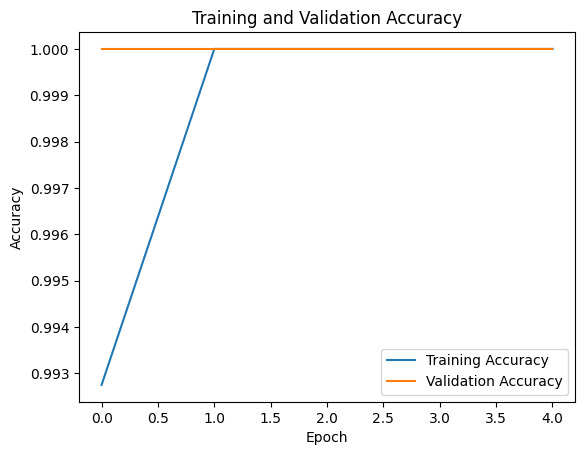

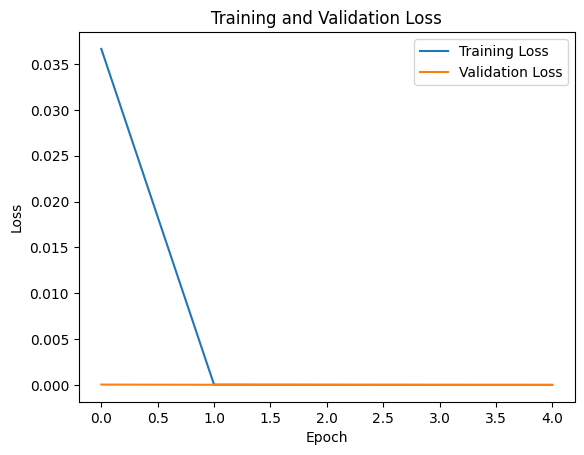

In [12]:
# Membangun model LSTM
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=5000, output_dim=128)) 
model_lstm.add(SpatialDropout1D(0.2))
model_lstm.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model_lstm.add(Dense(3, activation='softmax'))

# Mengonfigurasi model
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Menampilkan ringkasan model
model_lstm.summary()

# Melatih model
history_lstm = model_lstm.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_data=(X_test_pad, y_test), verbose=2)

# Evaluasi model
loss, accuracy = model_lstm.evaluate(X_test_pad, y_test, verbose=2)
print(f'Test Accuracy LSTM: {accuracy * 100:.2f}%')

# Menampilkan grafik akurasi dan loss selama pelatihan
# Plotting Training and Validation Accuracy
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting Training and Validation Loss
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Langkah 5: Percobaan 2 - Random Forest dengan TF-IDF
Percobaan kedua menggunakan model **Random Forest (RF)** dengan ekstraksi fitur **TF-IDF**. Pembagian data menggunakan **70/30**.

In [13]:
# TF-IDF Ekstraksi Fitur untuk percobaan 2
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

# Membangun Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Evaluasi Model
rf_accuracy = rf_model.score(X_test_tfidf, y_test)
print(f'Test Accuracy Random Forest: {rf_accuracy * 100:.2f}%')

Test Accuracy Random Forest: 100.00%


### Langkah 6: Percobaan 3 - LSTM dengan Word2Vec
Percobaan ketiga menggunakan model **LSTM** dengan ekstraksi fitur **Word2Vec**. Pembagian data menggunakan **80/20**.

In [14]:
import numpy as np
from gensim.models import Word2Vec

# Training Word2Vec
model_w2v = Word2Vec(sentences=[text.split() for text in X_train], vector_size=100, window=5, min_count=1, workers=4)
w2v_vocab = model_w2v.wv.key_to_index

def vectorize_text(text):
    # Menambahkan pengecekan jika tidak ada kata yang ditemukan di vocab
    vectors = [model_w2v.wv[word] for word in text.split() if word in w2v_vocab]
    if len(vectors) == 0: 
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([vectorize_text(text) for text in X_train])
X_test_w2v = np.array([vectorize_text(text) for text in X_test])

# Memeriksa apakah vektor sudah konsisten
print(X_train_w2v.shape)
print(X_test_w2v.shape)

# Membangun Model LSTM dengan Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_lstm_w2v = Sequential()
model_lstm_w2v.add(Embedding(input_dim=len(w2v_vocab), output_dim=100, input_length=100))
model_lstm_w2v.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model_lstm_w2v.add(Dense(3, activation='softmax'))
model_lstm_w2v.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Melatih Model
history_lstm_w2v = model_lstm_w2v.fit(X_train_w2v, y_train, epochs=5, batch_size=64, validation_data=(X_test_w2v, y_test), verbose=2)

# Evaluasi Model
loss, accuracy = model_lstm_w2v.evaluate(X_test_w2v, y_test, verbose=2)
print(f'Test Accuracy LSTM dengan Word2Vec: {accuracy * 100:.2f}%')


(8000, 100)
(2000, 100)
Epoch 1/5


d:\Submission\venv\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


125/125 - 13s - 106ms/step - accuracy: 0.9933 - loss: 0.0315 - val_accuracy: 1.0000 - val_loss: 2.0400e-05
Epoch 2/5
125/125 - 10s - 80ms/step - accuracy: 1.0000 - loss: 1.6647e-05 - val_accuracy: 1.0000 - val_loss: 1.1896e-05
Epoch 3/5
125/125 - 10s - 78ms/step - accuracy: 1.0000 - loss: 1.0726e-05 - val_accuracy: 1.0000 - val_loss: 8.4641e-06
Epoch 4/5
125/125 - 10s - 78ms/step - accuracy: 1.0000 - loss: 7.9210e-06 - val_accuracy: 1.0000 - val_loss: 6.3187e-06
Epoch 5/5
125/125 - 11s - 85ms/step - accuracy: 1.0000 - loss: 6.0955e-06 - val_accuracy: 1.0000 - val_loss: 5.0071e-06
63/63 - 1s - 17ms/step - accuracy: 1.0000 - loss: 5.0071e-06
Test Accuracy LSTM dengan Word2Vec: 100.00%
